# 02 - Extract Boundary Loops
Extract and analyze boundary loops from damaged meshes.

In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import load_config, ensure_dirs
from src.data.dataset_index import DatasetIndex
from src.data.sample_loader import SampleLoader
from src.geometry.boundary import extract_boundary_loops, loop_perimeter, loop_centroid
from src.target_selection.features import extract_loop_features

In [2]:
cfg = load_config(os.path.join(PROJECT_ROOT, 'configs', 'chair_leg.yaml'))
ensure_dirs(cfg)

index = DatasetIndex(cfg['paths']['raw_data_dir'])
loader = SampleLoader(cfg['paths']['raw_data_dir'])
print(f"Loaded {len(index)} samples")

Loaded 100 samples


In [3]:
# Analyze boundary loops across all samples
from tqdm import tqdm

loop_stats = []

for sid in tqdm(index.sample_ids, desc="Extracting loops"):
    try:
        sample = loader.load(sid)
        damaged = sample['damaged_mesh']
        removed = sample['removed_part_mesh']

        loops = extract_boundary_loops(damaged)

        perimeters = [loop_perimeter(damaged, l) for l in loops]

        loop_stats.append({
            'sample_id': sid,
            'n_loops': len(loops),
            'max_perimeter': max(perimeters) if perimeters else 0,
            'min_perimeter': min(perimeters) if perimeters else 0,
            'total_perimeter': sum(perimeters),
            'loop_sizes': [len(l) for l in loops],
        })
    except Exception as e:
        print(f"  Error on {sid}: {e}")

df_loops = pd.DataFrame(loop_stats)
print(f"\n--- Boundary Loop Statistics ---")
print(f"Mean loops per sample: {df_loops['n_loops'].mean():.2f}")
print(f"Max loops in a sample: {df_loops['n_loops'].max()}")
print(f"Samples with >1 loop: {(df_loops['n_loops'] > 1).sum()}")

Extracting loops: 100%|██████████████████████████████████████████████████████████████| 100/100 [02:07<00:00,  1.27s/it]


--- Boundary Loop Statistics ---
Mean loops per sample: 78.33
Max loops in a sample: 2888
Samples with >1 loop: 84


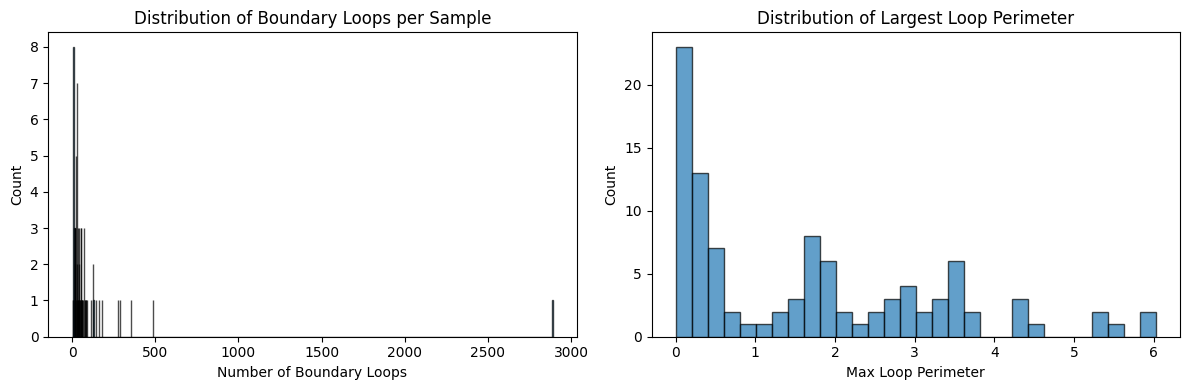

In [4]:
# Plot distribution of number of boundary loops
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_loops['n_loops'], bins=range(1, df_loops['n_loops'].max() + 2),
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Boundary Loops')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Boundary Loops per Sample')

axes[1].hist(df_loops['max_perimeter'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Max Loop Perimeter')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Largest Loop Perimeter')

plt.tight_layout()
plt.savefig(os.path.join(cfg['paths']['figures_dir'], 'boundary_loop_stats.pdf'),
            dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Detailed analysis on one sample
sid = index.sample_ids[0]
sample = loader.load(sid)
damaged = sample['damaged_mesh']
removed = sample['removed_part_mesh']
loops = extract_boundary_loops(damaged)

print(f"Sample {sid}: {len(loops)} boundary loops")
for i, loop in enumerate(loops):
    feats = extract_loop_features(damaged, loop, removed)
    print(f"  Loop {i}: {len(loop)} vertices, perimeter={feats['perimeter']:.4f}, "
          f"planarity={feats['planarity']:.4f}, dist_to_removed={feats['dist_to_removed']:.4f}")

Sample 2882: 128 boundary loops
  Loop 0: 28 vertices, perimeter=0.2469, planarity=0.0495, dist_to_removed=0.7446
  Loop 1: 29 vertices, perimeter=0.2653, planarity=0.1398, dist_to_removed=0.7456
  Loop 2: 28 vertices, perimeter=0.2366, planarity=0.0497, dist_to_removed=0.8560
  Loop 3: 29 vertices, perimeter=0.2699, planarity=0.1429, dist_to_removed=0.8576
  Loop 4: 26 vertices, perimeter=0.2274, planarity=0.0531, dist_to_removed=0.9678
  Loop 5: 26 vertices, perimeter=0.2413, planarity=0.0482, dist_to_removed=0.9687
  Loop 6: 28 vertices, perimeter=0.2299, planarity=0.0974, dist_to_removed=1.0785
  Loop 7: 26 vertices, perimeter=0.2191, planarity=0.0673, dist_to_removed=1.0787
  Loop 8: 27 vertices, perimeter=0.2343, planarity=0.0977, dist_to_removed=1.1911
  Loop 9: 28 vertices, perimeter=0.2336, planarity=0.0686, dist_to_removed=1.1921
  Loop 10: 28 vertices, perimeter=0.2495, planarity=0.0884, dist_to_removed=1.2999
  Loop 11: 28 vertices, perimeter=0.2256, planarity=0.0228, dist_